In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12})

# File paths
R_FILE = r'C:\AMR_Prediction_Project\Data\isolates_saureus_R.csv'
S_FILE = r'C:\AMR_Prediction_Project\Data\isolates_saureus_S.csv'

# Colour scheme used throughout
COLORS = {'Resistant': '#D85A30', 'Susceptible': '#1D9E75'}

print('Setup complete')

Setup complete


In [2]:
# Load both files
df_R = pd.read_csv(R_FILE)
df_S = pd.read_csv(S_FILE)

# Strip whitespace from column names (common NCBI formatting issue)
df_R.columns = df_R.columns.str.strip()
df_S.columns = df_S.columns.str.strip()

print('=== RAW DATA LOADED ===')
print(f'Resistant  : {len(df_R):,} isolates')
print(f'Susceptible: {len(df_S):,} isolates')
print(f'Total      : {len(df_R) + len(df_S):,} isolates')

=== RAW DATA LOADED ===
Resistant  : 979 isolates
Susceptible: 1,155 isolates
Total      : 2,134 isolates


In [3]:
# Dataset structure for resistant file
print('=== RESISTANT FILE STRUCTURE ===')
df_R.info()
print()
print('=== SUSCEPTIBLE FILE STRUCTURE ===')
df_S.info()

=== RESISTANT FILE STRUCTURE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 979 entries, 0 to 978
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   #Organism group      979 non-null    object 
 1   Strain               287 non-null    object 
 2   Isolate identifiers  979 non-null    object 
 3   Serovar              0 non-null      float64
 4   Isolate              979 non-null    object 
 5   Create date          979 non-null    object 
 6   Location             853 non-null    object 
 7   Isolation source     853 non-null    object 
 8   Isolation type       979 non-null    object 
 9   Food origin          0 non-null      float64
 10  SNP cluster          351 non-null    object 
 11  Min-same             349 non-null    float64
 12  Min-diff             6 non-null      float64
 13  BioSample            979 non-null    object 
 14  Assembly             825 non-null    object 
 15  AMR gen

In [4]:
# Missing values in key columns used for filtering
# Assembly is critical — without it we cannot download the genome
# AST phenotypes is critical — it tells us R or S for each antibiotic
print('=== MISSING VALUES (top 10 columns) ===')
print('\nResistant file:')
print(df_R.isnull().sum().sort_values(ascending=False).head(10))
print('\nSusceptible file:')
print(df_S.isnull().sum().sort_values(ascending=False).head(10))

=== MISSING VALUES (top 10 columns) ===

Resistant file:
Food origin         979
Computed types      979
Serovar             979
Min-diff            973
Strain              692
Min-same            630
SNP cluster         628
Assembly            154
Location            126
Isolation source    126
dtype: int64

Susceptible file:
Food origin         1155
Computed types      1155
Serovar             1155
Min-diff            1149
Strain               861
Min-same             721
SNP cluster          719
Assembly             132
Location             102
Isolation source     102
dtype: int64


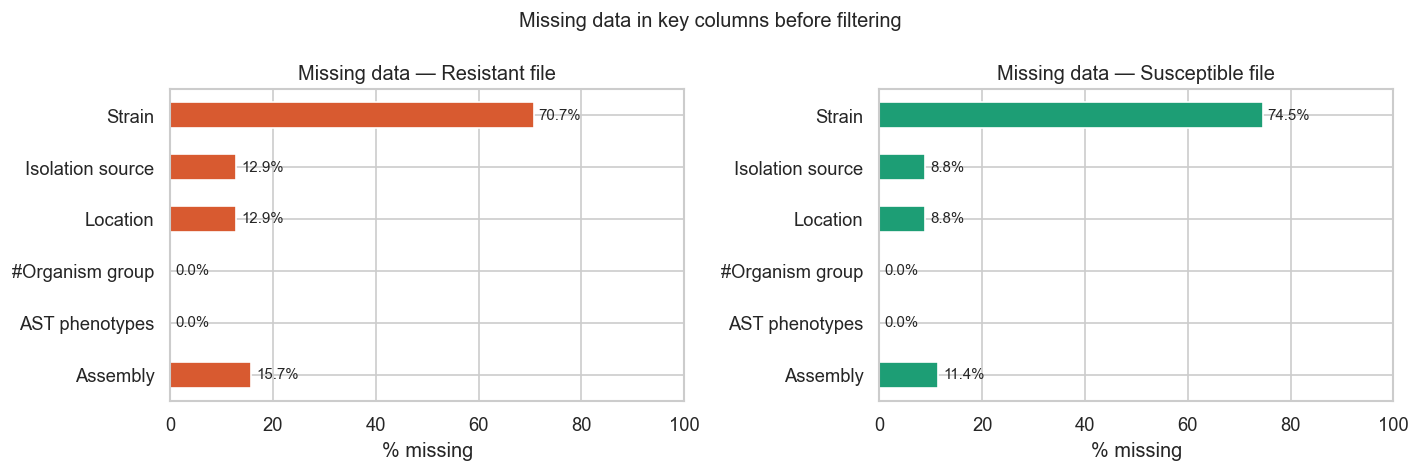

Note: Assembly missing means we cannot download that genome — these will be removed.


In [5]:
# Visualize missing data percentage for key columns
key_cols = ['Assembly', 'AST phenotypes', '#Organism group',
            'Location', 'Isolation source', 'Strain']

miss_r = df_R[key_cols].isnull().mean() * 100
miss_s = df_S[key_cols].isnull().mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, miss, title in zip(axes,
                            [miss_r, miss_s],
                            ['Resistant file', 'Susceptible file']):
    miss.plot(kind='barh', ax=ax, color='#D85A30' if 'Resist' in title else '#1D9E75')
    ax.set_xlabel('% missing')
    ax.set_title(f'Missing data — {title}')
    ax.set_xlim(0, 100)
    for i, v in enumerate(miss):
        ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('Missing data in key columns before filtering', fontsize=12)
plt.tight_layout()
plt.show()
print('Note: Assembly missing means we cannot download that genome — these will be removed.')

In [6]:
# What organisms are actually in the raw files?
# The files were labelled as E. coli but may contain related species (e.g. Shigella)
print('=== ORGANISM TYPES IN RAW FILES ===')
print('\nResistant file — top organisms:')
print(df_R['#Organism group'].value_counts().head(8))
print('\nSusceptible file — top organisms:')
print(df_S['#Organism group'].value_counts().head(8))

=== ORGANISM TYPES IN RAW FILES ===

Resistant file — top organisms:
Staphylococcus aureus              974
Staphylococcus pseudintermedius      5
Name: #Organism group, dtype: int64

Susceptible file — top organisms:
Staphylococcus aureus              1150
Staphylococcus pseudintermedius       5
Name: #Organism group, dtype: int64


In [7]:
r_before = len(df_R)
s_before = len(df_S)

# Filter to E. coli only (case-insensitive match on 'coli')
df_R = df_R[df_R['#Organism group'].str.contains('aureus', case=False, na=False)]
df_S = df_S[df_S['#Organism group'].str.contains('aureus', case=False, na=False)]

print('=== AFTER ORGANISM FILTER ===')
print(f'Resistant  : {r_before:,} → {len(df_R):,}  (removed {r_before - len(df_R):,})')
print(f'Susceptible: {s_before:,} → {len(df_S):,}  (removed {s_before - len(df_S):,})')

=== AFTER ORGANISM FILTER ===
Resistant  : 979 → 974  (removed 5)
Susceptible: 1,155 → 1,150  (removed 5)


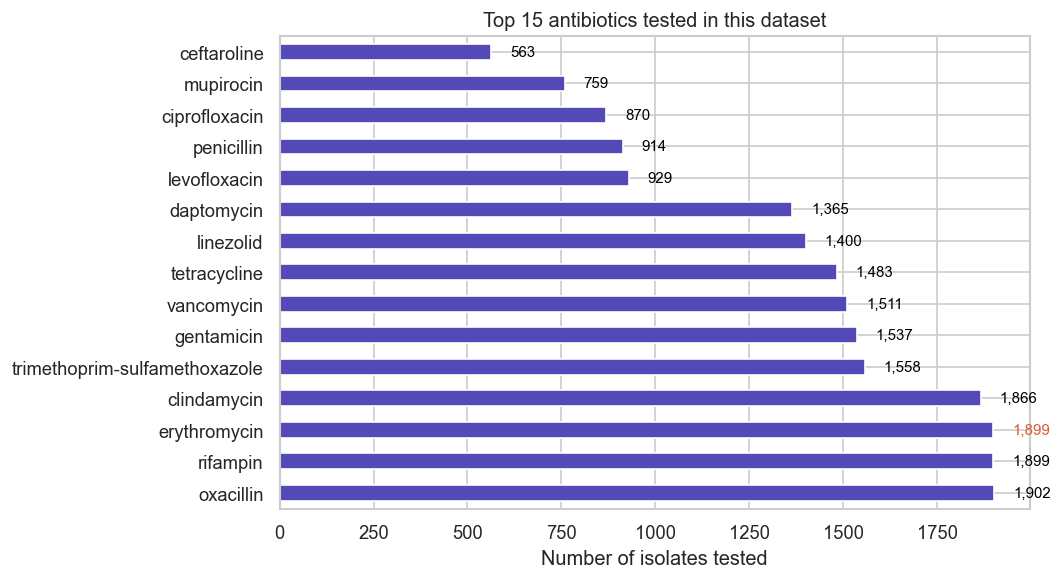

erythromycin isolate count: 1,899


In [8]:
# Count how many isolates have each antibiotic tested
# Combine both files temporarily for this overview
all_phenotypes = pd.concat([df_R['AST phenotypes'], df_S['AST phenotypes']]).dropna()

# Extract individual antibiotic names
antibiotic_list = []
for row in all_phenotypes:
    for pair in str(row).split(','):
        ab = pair.split('=')[0].strip().lower()
        if ab:
            antibiotic_list.append(ab)

ab_counts = pd.Series(antibiotic_list).value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 5))
ab_counts.plot(kind='barh', ax=ax, color='#534AB7')
ax.set_xlabel('Number of isolates tested')
ax.set_title('Top 15 antibiotics tested in this dataset')
# Highlight erthromycin
for i, (label, val) in enumerate(ab_counts.items()):
    color = '#D85A30' if label == 'erythromycin' else 'black'
    ax.text(val + 50, i, f'{val:,}', va='center', fontsize=9, color=color)
plt.tight_layout()
plt.show()
print(f'erythromycin isolate count: {ab_counts.get("erythromycin", 0):,}')

In [9]:
# Show what an AST phenotype string looks like
print('Example AST phenotype strings:')
print(df_R['AST phenotypes'].dropna().head(3).to_string())

Example AST phenotype strings:
5    ciprofloxacin=S,clindamycin=S,dicloxacillin=R,...
6    ciprofloxacin=R,clindamycin=S,daptomycin=S,ery...
7    cefoxitin=R,ceftaroline=S,clindamycin=S,daptom...


In [10]:
r_before = len(df_R)
s_before = len(df_S)

# Keep only isolates explicitly confirmed for erythromycin
# \b = word boundary ensures we match 'erythromycin=R' 
df_R = df_R[df_R['AST phenotypes'].str.contains(r'erythromycin=R\b', na=False)]
df_S = df_S[df_S['AST phenotypes'].str.contains(r'erythromycin=S\b', na=False)]

print('=== AFTER ERYTHROMYCIN FILTER ===')
print(f'Resistant  : {r_before:,} → {len(df_R):,}  (removed {r_before - len(df_R):,})')
print(f'Susceptible: {s_before:,} → {len(df_S):,}  (removed {s_before - len(df_S):,})')

=== AFTER ERYTHROMYCIN FILTER ===
Resistant  : 974 → 452  (removed 522)
Susceptible: 1,150 → 502  (removed 648)


In [11]:
r_before = len(df_R)
s_before = len(df_S)

print('Missing assemblies before removal:')
print(f'  Resistant  : {df_R["Assembly"].isna().sum():,}')
print(f'  Susceptible: {df_S["Assembly"].isna().sum():,}')

# Remove rows with no assembly accession
df_R = df_R[df_R['Assembly'].notna()]
df_S = df_S[df_S['Assembly'].notna()]

print(f'\nAfter assembly filter:')
print(f'Resistant  : {r_before:,} → {len(df_R):,}  (removed {r_before - len(df_R):,})')
print(f'Susceptible: {s_before:,} → {len(df_S):,}  (removed {s_before - len(df_S):,})')

Missing assemblies before removal:
  Resistant  : 83
  Susceptible: 65

After assembly filter:
Resistant  : 452 → 369  (removed 83)
Susceptible: 502 → 437  (removed 65)


In [12]:
r_before = len(df_R)
s_before = len(df_S)

print('Duplicate assemblies before removal:')
print(f'  Resistant  : {df_R["Assembly"].duplicated().sum():,}')
print(f'  Susceptible: {df_S["Assembly"].duplicated().sum():,}')

df_R = df_R.drop_duplicates(subset=['Assembly'])
df_S = df_S.drop_duplicates(subset=['Assembly'])

print(f'\nAfter duplicate removal:')
print(f'Resistant  : {r_before:,} → {len(df_R):,}  (removed {r_before - len(df_R):,})')
print(f'Susceptible: {s_before:,} → {len(df_S):,}  (removed {s_before - len(df_S):,})')

Duplicate assemblies before removal:
  Resistant  : 0
  Susceptible: 0

After duplicate removal:
Resistant  : 369 → 369  (removed 0)
Susceptible: 437 → 437  (removed 0)


In [13]:
r_before = len(df_R)
s_before = len(df_S)

# Find assemblies appearing in both files
common = set(df_R['Assembly']).intersection(set(df_S['Assembly']))

print(f'Assemblies appearing in BOTH R and S files: {len(common):,}')
if len(common) > 0 and len(common) <= 5:
    print(f'Examples: {list(common)}')

# Remove conflicting assemblies from both
df_R = df_R[~df_R['Assembly'].isin(common)]
df_S = df_S[~df_S['Assembly'].isin(common)]

print(f'\nAfter conflict removal:')
print(f'Resistant  : {r_before:,} → {len(df_R):,}')
print(f'Susceptible: {s_before:,} → {len(df_S):,}')

Assemblies appearing in BOTH R and S files: 0

After conflict removal:
Resistant  : 369 → 369
Susceptible: 437 → 437


In [14]:
# Assign binary labels
df_R['label'] = 1   # Resistant
df_S['label'] = 0   # Susceptible

# Merge both cleaned files
df = pd.concat([df_R, df_S], ignore_index=True)

print('=== MERGED DATASET (before balancing) ===')
print(f'Total isolates: {len(df):,}')
print(f'\nClass distribution:')
print(df['label'].value_counts().rename({1:'Resistant', 0:'Susceptible'}))
print(f'\nClass balance: {df["label"].value_counts(normalize=True).round(3).to_dict()}')

=== MERGED DATASET (before balancing) ===
Total isolates: 806

Class distribution:
Susceptible    437
Resistant      369
Name: label, dtype: int64

Class balance: {0: 0.542, 1: 0.458}


In [15]:
print('=== INTEGRITY CHECKS ===')

checks = {
    'No duplicate assemblies':
        df['Assembly'].duplicated().sum() == 0,
    'No missing assemblies':
        df['Assembly'].isna().sum() == 0,
    'No missing labels':
        df['label'].isna().sum() == 0,
    'Labels are 0 or 1 only':
        set(df['label'].unique()) == {0, 1},
    'R label matches erythromycin=R phenotype':
        df[df.label == 1]['AST phenotypes'].str.contains('erythromycin=R').sum() == (df.label == 1).sum(),
    'S label matches erythromycin=S phenotype':
        df[df.label == 0]['AST phenotypes'].str.contains('erythromycin=S').sum() == (df.label == 0).sum(),
}

all_passed = True
for check, result in checks.items():
    status = 'PASS' if result else 'FAIL'
    if not result:
        all_passed = False
    print(f'  [{status}] {check}')

print(f'\n{"All checks passed" if all_passed else "WARNING: some checks failed"}')

=== INTEGRITY CHECKS ===
  [PASS] No duplicate assemblies
  [PASS] No missing assemblies
  [PASS] No missing labels
  [PASS] Labels are 0 or 1 only
  [PASS] R label matches erythromycin=R phenotype
  [PASS] S label matches erythromycin=S phenotype

All checks passed


In [16]:
print('=== BEFORE BALANCING ===')
r_count = (df['label'] == 1).sum()
s_count = (df['label'] == 0).sum()
print(f'Resistant  : {r_count:,}')
print(f'Susceptible: {s_count:,}')
print(f'Imbalance  : {max(r_count, s_count)/min(r_count, s_count):.1f}x')

# Balance: take all of the smaller class and sample same number from larger class
df_R_bal = df[df.label == 1]
df_S_bal = df[df.label == 0].sample(n=len(df_R_bal), random_state=42)

df_balanced = pd.concat([df_R_bal, df_S_bal])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print('\n=== AFTER BALANCING ===')
print(f'Resistant  : {(df_balanced["label"]==1).sum():,}')
print(f'Susceptible: {(df_balanced["label"]==0).sum():,}')
print(f'Total      : {len(df_balanced):,}')
print(f'Balance    : {df_balanced["label"].value_counts(normalize=True).round(3).to_dict()}')

=== BEFORE BALANCING ===
Resistant  : 369
Susceptible: 437
Imbalance  : 1.2x

=== AFTER BALANCING ===
Resistant  : 369
Susceptible: 369
Total      : 738
Balance    : {1: 0.5, 0: 0.5}


In [17]:
# Final unique assembly check
print(f'Unique assemblies in balanced dataset: {df_balanced["Assembly"].nunique():,}')
print(f'Total rows: {len(df_balanced):,}')
print(f'Match (no hidden duplicates): {df_balanced["Assembly"].nunique() == len(df_balanced)}')

Unique assemblies in balanced dataset: 738
Total rows: 738
Match (no hidden duplicates): True


In [18]:
# Convert to string first (VERY IMPORTANT)
df_balanced["Location"] = df_balanced["Location"].astype(str)
df_balanced["Isolation source"] = df_balanced["Isolation source"].astype(str)
df_balanced["Food origin"] = df_balanced["Food origin"].astype(str)

# Now apply string operations
df_balanced["Country"] = df_balanced["Location"].str.split(":").str[0].str.strip()

df_balanced["Isolation source"] = df_balanced["Isolation source"].str.lower().str.strip()
df_balanced["Food origin"] = df_balanced["Food origin"].str.lower().str.strip()

print("Country extraction done")
print(df_balanced["Country"].value_counts().head(10))

Country extraction done
USA           464
Australia     235
nan            25
Russia          9
Argentina       3
Kazakhstan      2
Name: Country, dtype: int64


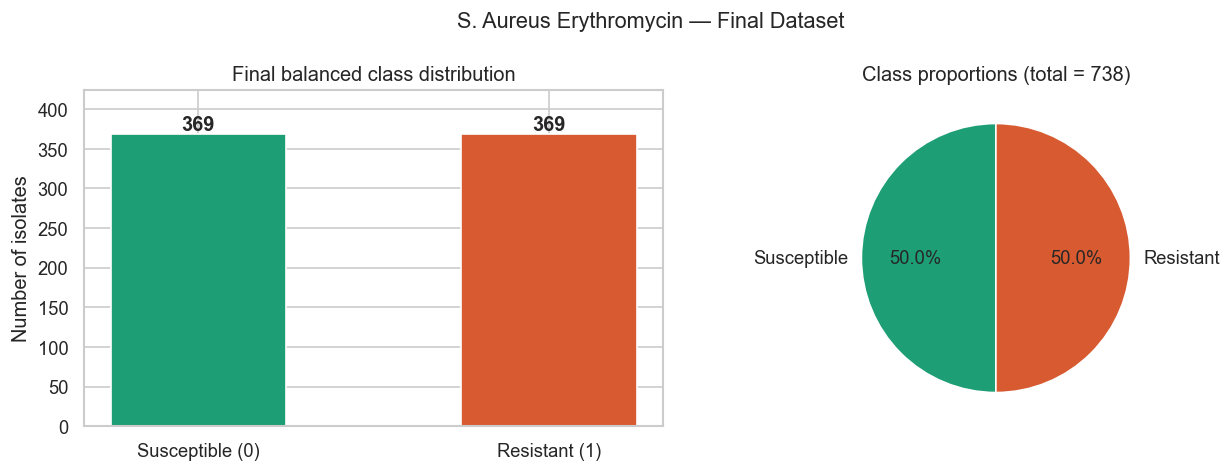

In [19]:
# ── Plot 1: Final class distribution ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
counts = df_balanced['label'].value_counts()
axes[0].bar(['Susceptible (0)', 'Resistant (1)'],
            [counts[0], counts[1]],
            color=[COLORS['Susceptible'], COLORS['Resistant']],
            width=0.5)
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 5, f'{v:,}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of isolates')
axes[0].set_title('Final balanced class distribution')
axes[0].set_ylim(0, max(counts) * 1.15)

# Pie chart
axes[1].pie([counts[0], counts[1]],
            labels=['Susceptible', 'Resistant'],
            colors=[COLORS['Susceptible'], COLORS['Resistant']],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title(f'Class proportions (total = {len(df_balanced):,})')

plt.suptitle('S. Aureus Erythromycin — Final Dataset', fontsize=13)
plt.tight_layout()
plt.show()

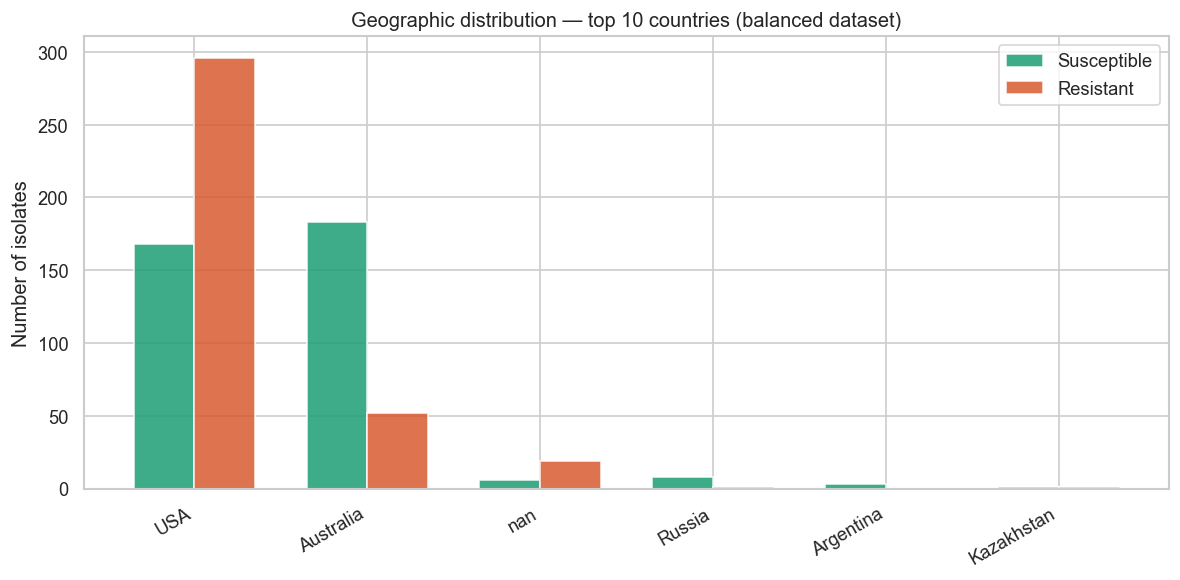


Resistance rate by country (top 10):
            Susceptible  Resistant  Total  Resistance %
Country                                                
USA                 168        296    464          63.8
Australia           183         52    235          22.1
nan                   6         19     25          76.0
Russia                8          1      9          11.1
Argentina             3          0      3           0.0
Kazakhstan            1          1      2          50.0


In [20]:
# ── Plot 2: Geographic distribution ──────────────────────────────
country_label = pd.crosstab(df_balanced['Country'], df_balanced['label'])
country_label.columns = ['Susceptible', 'Resistant']
country_label['Total'] = country_label.sum(axis=1)
top_countries = country_label.sort_values('Total', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(top_countries))
w = 0.35
ax.bar([i - w/2 for i in x], top_countries['Susceptible'], w,
       label='Susceptible', color=COLORS['Susceptible'], alpha=0.85)
ax.bar([i + w/2 for i in x], top_countries['Resistant'], w,
       label='Resistant', color=COLORS['Resistant'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top_countries.index, rotation=30, ha='right')
ax.set_ylabel('Number of isolates')
ax.set_title('Geographic distribution — top 10 countries (balanced dataset)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nResistance rate by country (top 10):')
top_countries['Resistance %'] = (top_countries['Resistant'] / top_countries['Total'] * 100).round(1)
print(top_countries[['Susceptible', 'Resistant', 'Total', 'Resistance %']])

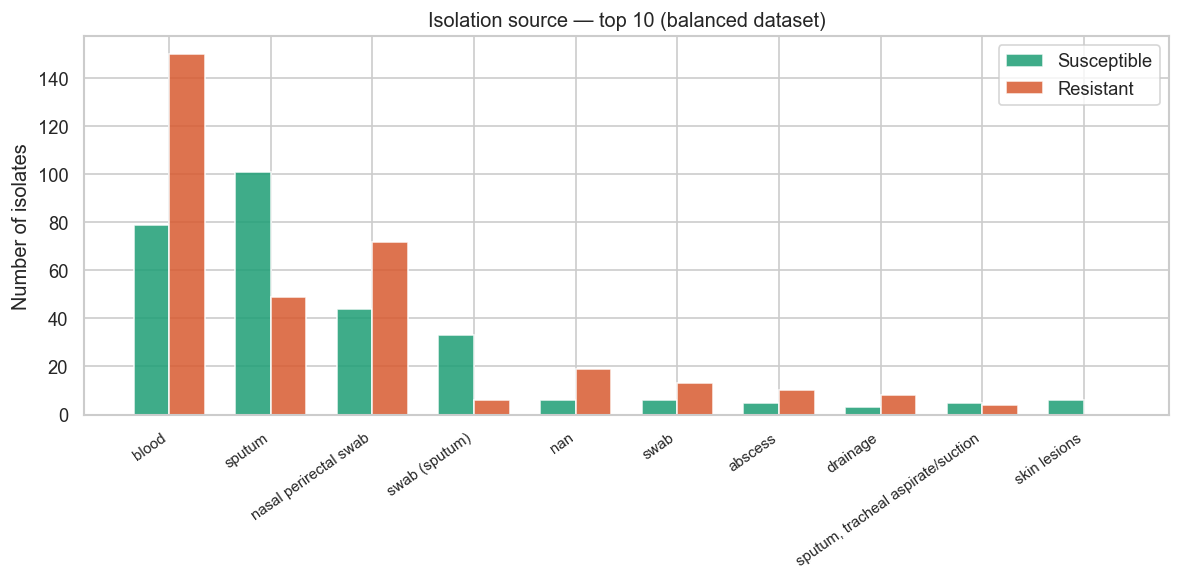

In [21]:
# ── Plot 3: Isolation source distribution ────────────────────────
source_label = pd.crosstab(df_balanced['Isolation source'], df_balanced['label'])
source_label.columns = ['Susceptible', 'Resistant']
source_label['Total'] = source_label.sum(axis=1)
top_sources = source_label.sort_values('Total', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(top_sources))
ax.bar([i - w/2 for i in x], top_sources['Susceptible'], w,
       label='Susceptible', color=COLORS['Susceptible'], alpha=0.85)
ax.bar([i + w/2 for i in x], top_sources['Resistant'], w,
       label='Resistant', color=COLORS['Resistant'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top_sources.index, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Number of isolates')
ax.set_title('Isolation source — top 10 (balanced dataset)')
ax.legend()
plt.tight_layout()
plt.show()

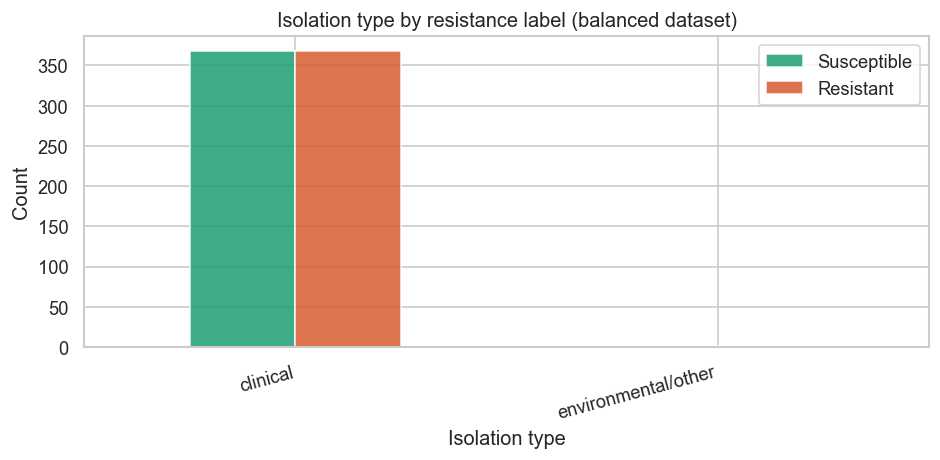

In [22]:
# ── Plot 4: Isolation type (clinical vs food vs environmental) ───
type_counts = df_balanced.groupby(['Isolation type', 'label']).size().unstack(fill_value=0)
type_counts.columns = ['Susceptible', 'Resistant']

type_counts.plot(kind='bar', figsize=(8, 4),
                 color=[COLORS['Susceptible'], COLORS['Resistant']],
                 alpha=0.85)
plt.title('Isolation type by resistance label (balanced dataset)')
plt.xlabel('Isolation type')
plt.ylabel('Count')
plt.xticks(rotation=15, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Update these values from your actual script output
pipeline_stages = [
    ('Raw download',              979,  1155),
    ('After organism filter',     974,  1150),
    ('After antibiotic filter',   452,  502),
    ('After assembly filter',     369, 437 ),
    ('After duplicate removal',   369,  437),
    ('After conflict removal',    369,  437),
    ('After balancing',           369,  369),
]

stages  = [s[0] for s in pipeline_stages]
r_vals  = [s[1] for s in pipeline_stages]
s_vals  = [s[2] for s in pipeline_stages]

# Summary table
summary_df = pd.DataFrame({
    'Stage'      : stages,
    'Resistant'  : r_vals,
    'Susceptible': s_vals,
    'Total'      : [r+s for r,s in zip(r_vals, s_vals)]
})
print(summary_df.to_string(index=False))

                  Stage  Resistant  Susceptible  Total
           Raw download        979         1155   2134
  After organism filter        974         1150   2124
After antibiotic filter        452          502    954
  After assembly filter        369          437    806
After duplicate removal        369          437    806
 After conflict removal        369          437    806
        After balancing        369          369    738


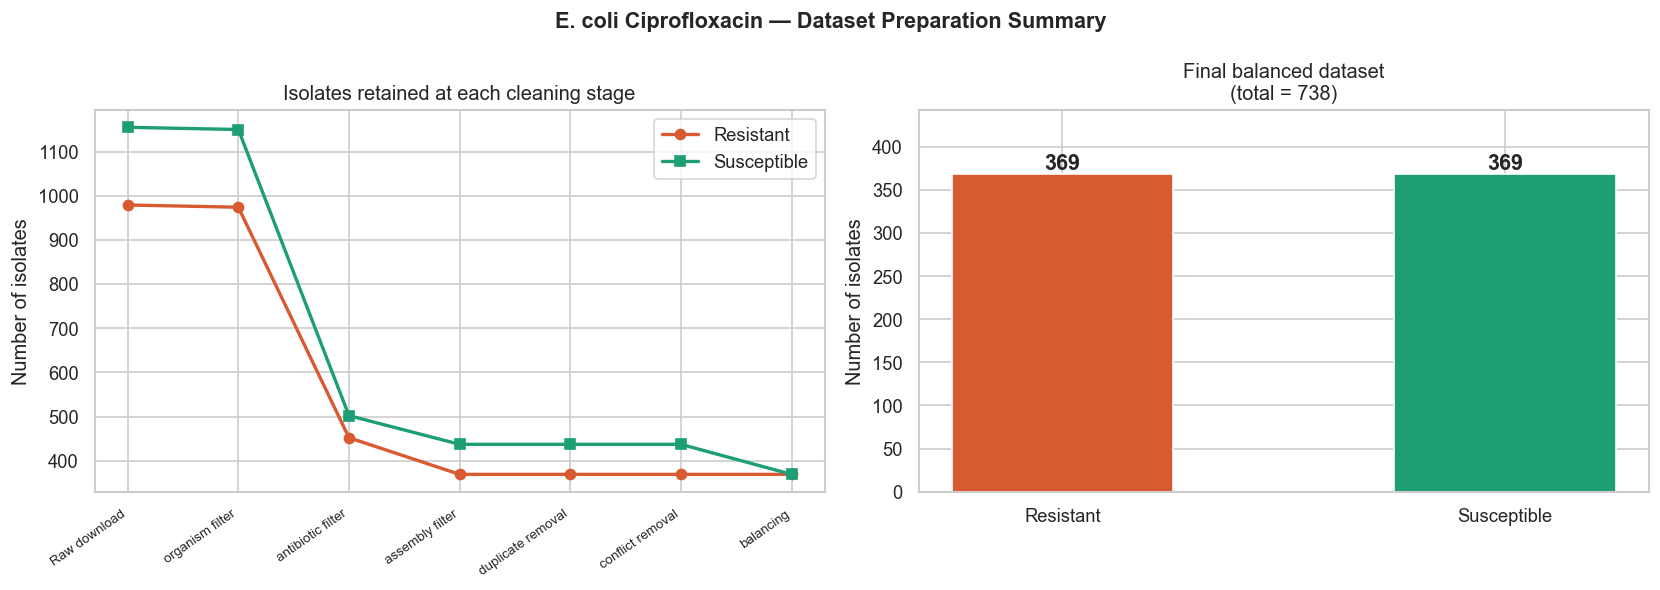

In [24]:
# Funnel visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line plot — size at each stage
axes[0].plot(range(len(stages)), r_vals, 'o-',
             color=COLORS['Resistant'], lw=2, label='Resistant')
axes[0].plot(range(len(stages)), s_vals, 's-',
             color=COLORS['Susceptible'], lw=2, label='Susceptible')
axes[0].set_xticks(range(len(stages)))
axes[0].set_xticklabels([s.replace('After ', '') for s in stages],
                         rotation=35, ha='right', fontsize=8)
axes[0].set_ylabel('Number of isolates')
axes[0].set_title('Isolates retained at each cleaning stage')
axes[0].legend()

# Bar chart — final state
final_r = r_vals[-1]
final_s = s_vals[-1]
bars = axes[1].bar(['Resistant', 'Susceptible'],
                   [final_r, final_s],
                   color=[COLORS['Resistant'], COLORS['Susceptible']],
                   width=0.5)
for bar, val in zip(bars, [final_r, final_s]):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 5,
                 f'{val:,}', ha='center', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, max(final_r, final_s) * 1.2)
axes[1].set_ylabel('Number of isolates')
axes[1].set_title(f'Final balanced dataset\n(total = {final_r + final_s:,})')

plt.suptitle('E. coli Ciprofloxacin — Dataset Preparation Summary',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()